# Proyek Analisis Data: E-Commerce Dataset
- **Nama:** Alifya Dinda Salsabilla
- **Email:** 23430001.alifya@tsu.ac.id
- **ID Dicoding:** CDCC899D6X1478

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Seberapa besar kontribusi 20% pelanggan dengan nilai transaksi tertinggi terhadap total revenue selama periode 2016–2018?
- **Pertanyaan 2:** Produk apa saja yang memberikan kontribusi terbesar terhadap total revenue selama periode 2016–2018?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Wrangling

### Gathering Data

In [2]:
orders = pd.read_csv('/content/data_1.csv')
order_items = pd.read_csv('/content/data_2.csv')

orders.head()
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight:**

- Data yang digunakan terdiri dari dua tabel utama, yaitu data pesanan dan detail item dalam pesanan. Kedua tabel ini saling melengkapi, di mana tabel orders memberikan informasi transaksi secara umum, sedangkan order_items memberikan detail harga dan produk. Artinya, untuk mendapatkan informasi revenue yang akurat, kedua data ini harus digabungkan.

### Assessing Data

In [3]:
orders.info()
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 

In [4]:
orders.isnull().sum()
order_items.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [5]:
orders.duplicated().sum()
order_items.duplicated().sum()

np.int64(0)

**Insight:**

- Dari eksplorasi awal, terlihat bahwa dataset memiliki struktur yang cukup jelas dengan kombinasi data kategorikal, numerik, dan waktu. Keberadaan kolom timestamp memungkinkan analisis berbasis waktu, sementara data harga dapat digunakan untuk menghitung revenue. Namun, ditemukan juga beberapa nilai yang hilang, yang menunjukkan bahwa data belum sepenuhnya bersih. Selain itu, tidak ditemukan duplikasi yang signifikan, sehingga kualitas data secara umum cukup baik untuk dianalisis lebih lanjut setelah dilakukan pembersihan.

### Cleaning Data

In [6]:
df = orders.merge(order_items, on='order_id', how='left')


In [7]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df = df[df['order_status'] == 'delivered']

df.dropna(subset=['price'], inplace=True)


In [8]:
df['total_price'] = df['price'] + df['freight_value']


**Insight:**
- Proses pembersihan difokuskan pada memastikan bahwa hanya transaksi yang valid yang digunakan dalam analisis, yaitu transaksi dengan status "delivered". Hal ini penting agar hasil analisis tidak bias oleh transaksi yang dibatalkan atau gagal. Selain itu, pembuatan variabel total_price membantu menyederhanakan analisis dengan menggabungkan harga produk dan biaya pengiriman menjadi satu nilai transaksi. Langkah ini membuat perhitungan revenue menjadi lebih representatif.

## Exploratory Data Analysis (EDA)

### Explore Data

In [9]:
df.describe()
df.head()
df['total_price'].describe()


,total_price
count,110197.000000
mean,139.929161
std,189.319151
min,6.080000
25%,55.180000
50%,92.130000
75%,157.510000
max,6929.310000


**Insight:**

- Dari hasil eksplorasi awal, terlihat bahwa nilai transaksi memiliki variasi yang cukup besar. Hal ini menunjukkan bahwa tidak semua transaksi memiliki nilai yang sama, dan kemungkinan terdapat perbedaan perilaku antar pelanggan, baik dari segi jumlah pembelian maupun nilai transaksi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

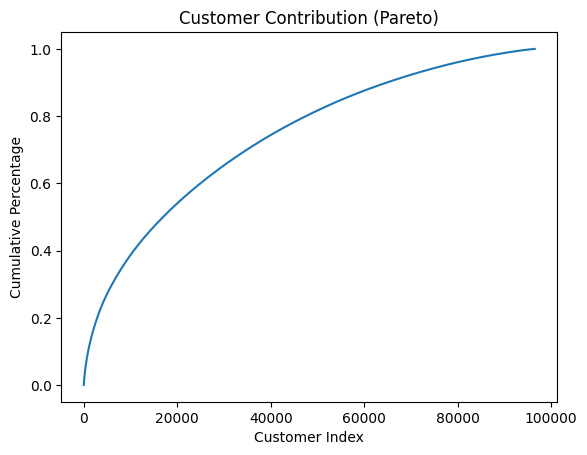

In [10]:
customer_data = df.groupby('customer_id')['total_price'].sum().sort_values(ascending=False)

customer_data = customer_data.reset_index()

customer_data['cum_sum'] = customer_data['total_price'].cumsum()
customer_data['cum_perc'] = customer_data['cum_sum'] / customer_data['total_price'].sum()

import matplotlib.pyplot as plt

plt.plot(customer_data['cum_perc'])
plt.title("Customer Contribution (Pareto)")
plt.xlabel("Customer Index")
plt.ylabel("Cumulative Percentage")
plt.show()


**Insight:**

- Hasil analisis menunjukkan bahwa kontribusi pelanggan terhadap revenue tidak merata. Sebagian besar pelanggan hanya memberikan kontribusi kecil, sementara ada kelompok pelanggan tertentu yang menyumbang sebagian besar pendapatan.
- Pola ini menunjukkan bahwa bisnis sangat bergantung pada pelanggan dengan nilai transaksi tinggi. Jika pelanggan-pelanggan ini hilang, maka dampaknya terhadap revenue bisa cukup signifikan. Oleh karena itu, penting untuk menjaga loyalitas pelanggan yang memberikan kontribusi besar ini.


### Pertanyaan 2:

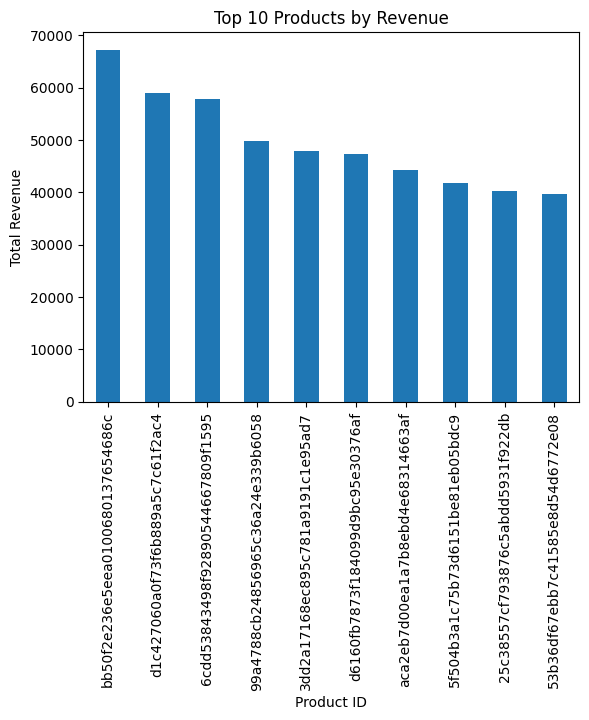

In [11]:
product_data = df.groupby('product_id')['total_price'].sum().sort_values(ascending=False).head(10)

product_data.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product ID")
plt.ylabel("Total Revenue")
plt.show()


**Insight:**
- Analisis produk menunjukkan bahwa tidak semua produk memiliki peran yang sama dalam menghasilkan revenue. Hanya beberapa produk yang secara konsisten memberikan kontribusi besar, sementara sebagian besar produk lainnya memiliki kontribusi yang relatif kecil.
- Hal ini menunjukkan bahwa penjualan cenderung terpusat pada produk-produk tertentu. Dengan memahami produk mana yang paling berkontribusi, bisnis dapat lebih fokus dalam strategi pemasaran dan pengelolaan stok.

In [12]:
import pandas as pd

# pastikan timestamp sudah datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# buat snapshot date (tanggal acuan)
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# buat RFM
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'total_price': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']

rfm.head()


,recency,frequency,monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,288,1,114.74
000161a058600d5901f007fab4c27140,410,1,67.41
0001fd6190edaaf884bcaf3d49edf079,548,1,195.42
0002414f95344307404f0ace7a26f1d5,379,1,179.35
000379cdec625522490c315e70c7a9fb,150,1,107.01


#Insight:


*   Analisis RFM menunjukkan bahwa terdapat variasi perilaku pelanggan berdasarkan waktu terakhir transaksi, frekuensi pembelian, dan total pengeluaran. Pelanggan dengan nilai recency rendah, frequency tinggi, dan monetary besar cenderung menjadi pelanggan yang paling berkontribusi terhadap revenue.




In [13]:
# ======================
# CLUSTERING (MANUAL)
# ======================

rfm['segment'] = 'Low Value'

rfm.loc[
    (rfm['monetary'] > rfm['monetary'].quantile(0.75)) &
    (rfm['frequency'] > rfm['frequency'].quantile(0.75)),
    'segment'
] = 'High Value'

rfm.loc[
    (rfm['recency'] < rfm['recency'].quantile(0.25)) &
    (rfm['frequency'] > rfm['frequency'].quantile(0.5)),
    'segment'
] = 'Loyal Customer'

rfm.head()


,recency,frequency,monetary,segment
customer_id,,,,
00012a2ce6f8dcda20d059ce98491703,288,1,114.74,Low Value
000161a058600d5901f007fab4c27140,410,1,67.41,Low Value
0001fd6190edaaf884bcaf3d49edf079,548,1,195.42,Low Value
0002414f95344307404f0ace7a26f1d5,379,1,179.35,Low Value
000379cdec625522490c315e70c7a9fb,150,1,107.01,Low Value


<Axes: xlabel='segment'>

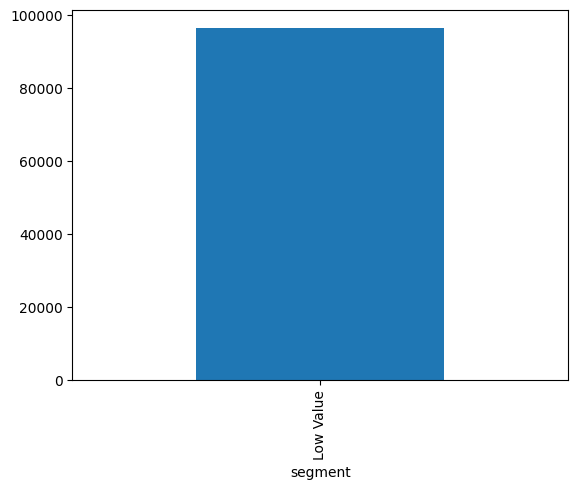

In [14]:
rfm['segment'].value_counts().plot(kind='bar')


# insight :

*   Segmentasi pelanggan menunjukkan bahwa terdapat beberapa kelompok pelanggan berdasarkan nilai transaksi dan frekuensi pembelian. Pelanggan dengan kategori High Value memiliki kontribusi terbesar terhadap revenue, sementara Loyal Customer menunjukkan pelanggan yang aktif bertransaksi dalam periode terbaru. Di sisi lain, pelanggan dengan kategori Low Value memiliki kontribusi yang relatif kecil dan berpotensi untuk ditingkatkan melalui strategi pemasaran.




## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan analisis kontribusi pelanggan, sekitar 20% pelanggan teratas memberikan kontribusi yang sangat signifikan terhadap total revenue. Hal ini menunjukkan adanya pola distribusi yang tidak merata, di mana sebagian kecil pelanggan memiliki peran dominan dalam menghasilkan pendapatan. Temuan ini juga selaras dengan hasil analisis RFM, di mana pelanggan dengan nilai frequency dan monetary yang tinggi cenderung masuk dalam kelompok pelanggan utama. Oleh karena itu, mempertahankan pelanggan dalam kelompok ini menjadi strategi yang penting untuk menjaga stabilitas dan pertumbuhan revenue.




- **Conclusion pertanyaan 2:** Dari sisi produk Hasil analisis menunjukkan bahwa terdapat beberapa produk yang memiliki kontribusi paling besar terhadap total revenue dibandingkan produk lainnya. Produk-produk tersebut menjadi pendorong utama penjualan karena memiliki tingkat permintaan yang lebih tinggi atau nilai transaksi yang lebih besar. Dominasi produk tertentu ini mengindikasikan bahwa strategi bisnis dapat difokuskan pada optimalisasi produk unggulan, baik dari sisi stok, promosi, maupun peningkatan kualitas, agar dapat terus meningkatkan kontribusi terhadap revenue secara keseluruhan.

**Rekomendasi Action Item:**
- Fokus mempertahankan customer dengan nilai transaksi tinggi
- Optimalkan penjualan pada produk yang sudah terbukti laku
- Manfaatkan periode dengan penjualan tinggi untuk strategi promosi

In [15]:
df.to_csv('main_data.csv', index=False)
